# Exploratory Data Analysis: ServiceNow-Armis Enterprise Risk Assessment

**Course:** ALY 6130 - Risk Management Analytics  
**Group 4:** Adwoa Bempomaa, Sara Mathai, Lawrence Dass  
**Date:** March 2026

This notebook performs exploratory data analysis on the full 25-risk enterprise register,
KRI framework, and Monte Carlo simulation parameters.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Libraries imported.')

Libraries imported.


## 1. Risk Register Overview

In [8]:
risk_register = pd.DataFrame({
    'Risk_ID': ['R3','R19','R20','R2','R1','R13','R17','R23','R15','R5',
                'R6','R7','R8','R9','R10','R11','R12','R14','R16','R24',
                'R18','R4','R21','R22','R25'],
    'Risk_Name': [
        'Regulatory-Driven Demand Acceleration',
        'OT/IoT Security Market Growth',
        'Cross-Sell Revenue via Existing Customer Base',
        'AI-Driven Platform Convergence Risk',
        'Competitive Displacement by Rival Mega-Acquisitions',
        'AI Technology Obsolescence',
        'Customer Migration to Competitor Platforms',
        'AI Governance and Regulatory Ethics Risk',
        'Legal Liability from Compliance Failures',
        'Acquisition Overvaluation Risk',
        'Integration Overload from Multi-Acquisition Complexity',
        'Technology Architecture Incompatibility',
        'Cybersecurity Talent Shortage',
        'Post-Acquisition Organisational Disruption',
        'Asset Visibility Data Accuracy Gaps',
        'Infrastructure Instability During Integration',
        'Security Vulnerabilities During Merger Integration',
        'Global Regulatory Compliance Complexity',
        'Infrastructure and Cloud Cost Expansion',
        'Third-Party Cloud Infrastructure Dependency',
        'Economic Slowdown Reducing Cybersecurity Spend',
        'Cybersecurity Market Consolidation Pressure',
        'Minor Operational Workflow Misalignment',
        'Short-Term Customer Transition Uncertainty',
        'Vendor Lock-In Limiting Technology Flexibility'
    ],
    'Category': ['Regulatory','Market','Market','Strategic','Strategic','Strategic',
                 'Strategic','Regulatory','Regulatory','Financial','Operational',
                 'Technical','Operational','Operational','Technical','Operational',
                 'Technical','Regulatory','Financial','Technical','Market',
                 'Strategic','Operational','Market','Technical'],
    'Risk_Type': ['Positive','Positive','Positive','Negative','Negative','Negative',
                  'Negative','Negative','Negative','Negative','Negative','Negative',
                  'Negative','Negative','Negative','Negative','Negative','Negative',
                  'Negative','Negative','Negative','Negative','Negative','Negative','Negative'],
    'Likelihood': [9,7,7,7,7,7,7,5,7,5,5,5,5,5,5,5,5,5,5,5,5,5,3,3,3],
    'Impact':     [8,8,8,9,8,8,8,9,6,8,6,6,6,6,6,6,6,6,6,6,6,6,4,2,6],
    'Risk_Score': [72,56,56,63,56,56,56,45,42,40,30,30,30,30,30,30,30,30,30,30,30,30,12,6,18],
    'Priority':   ['HIGH','HIGH','HIGH','HIGH','HIGH','HIGH','HIGH','HIGH',
                   'MEDIUM','MEDIUM','MEDIUM','MEDIUM','MEDIUM','MEDIUM','MEDIUM',
                   'MEDIUM','MEDIUM','MEDIUM','MEDIUM','MEDIUM','MEDIUM','MEDIUM',
                   'LOW','LOW','LOW'],
    'KRI_Status': ['Green','Amber','Amber','Amber','Amber','Amber','Amber','Amber',
                   'Amber','Amber','Amber','Amber','Amber','Amber','Amber','Amber',
                   'Amber','Amber','Amber','Red','Amber','Amber','Amber','Amber','Amber'],
    'Expected_Value_M': [198.0,81.7,71.2,-84.0,-65.3,-54.8,-50.2,-41.7,
                         -30.3,-75.0,-10.8,-10.8,-9.7,-9.7,-6.7,-6.7,-10.8,
                         -6.7,-10.8,-6.7,-10.8,-9.7,-0.75,-0.60,-1.80]
})

print(f'Total risks: {len(risk_register)}')
print(f'Positive risks: {(risk_register.Risk_Type=="Positive").sum()}')
print(f'Negative risks: {(risk_register.Risk_Type=="Negative").sum()}')
print(f'HIGH priority: {(risk_register.Priority=="HIGH").sum()}')
print(f'MEDIUM priority: {(risk_register.Priority=="MEDIUM").sum()}')
print(f'LOW priority: {(risk_register.Priority=="LOW").sum()}')
risk_register.head()

Total risks: 25
Positive risks: 3
Negative risks: 22
HIGH priority: 8
MEDIUM priority: 14
LOW priority: 3


,Risk_ID,Risk_Name,Category,Risk_Type,Likelihood,Impact,Risk_Score,Priority,KRI_Status,Expected_Value_M
0,R3,Regulatory-Driven Demand Acceleration,Regulatory,Positive,9,8,72,HIGH,Green,198.0
1,R19,OT/IoT Security Market Growth,Market,Positive,7,8,56,HIGH,Amber,81.7
2,R20,Cross-Sell Revenue via Existing Customer Base,Market,Positive,7,8,56,HIGH,Amber,71.2
3,R2,AI-Driven Platform Convergence Risk,Strategic,Negative,7,9,63,HIGH,Amber,-84.0
4,R1,Competitive Displacement by Rival Mega-Acquisi...,Strategic,Negative,7,8,56,HIGH,Amber,-65.3


## 2. Risk Score Distribution by Category

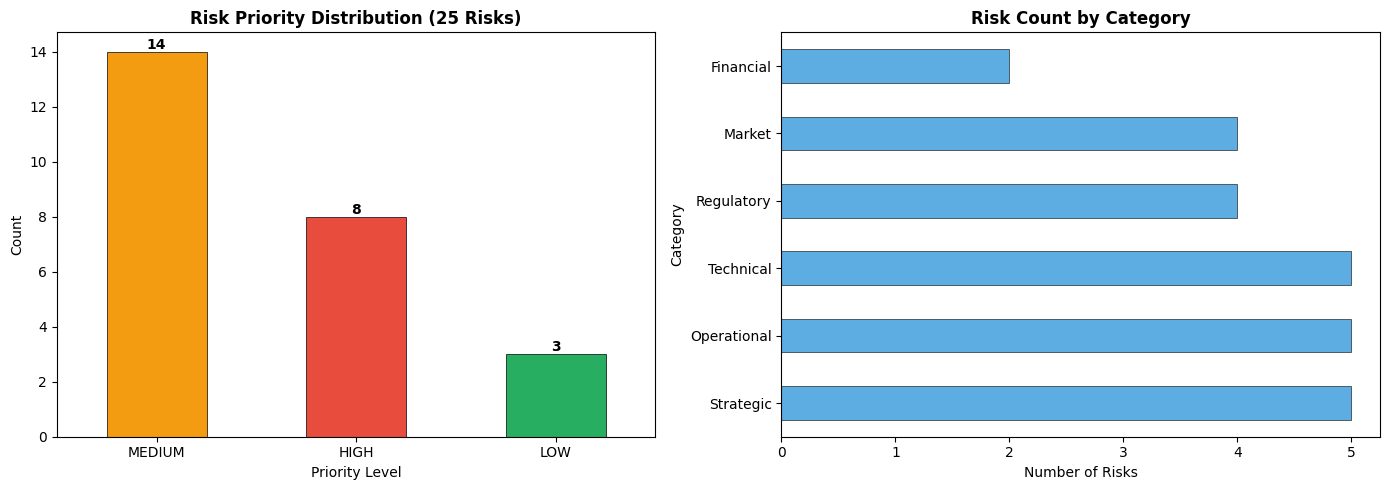

Saved: eda_priority_category.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Priority distribution
pri_counts = risk_register['Priority'].value_counts()
colors_pri = {'HIGH': '#E74C3C', 'MEDIUM': '#F39C12', 'LOW': '#27AE60'}
pri_counts.plot(kind='bar', ax=axes[0],
                color=[colors_pri[p] for p in pri_counts.index],
                edgecolor='black', linewidth=0.5)
axes[0].set_title('Risk Priority Distribution (25 Risks)', fontweight='bold')
axes[0].set_xlabel('Priority Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0].patches, pri_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', fontweight='bold')

# Category distribution
cat_counts = risk_register['Category'].value_counts()
cat_counts.plot(kind='barh', ax=axes[1], color='#3498DB',
                edgecolor='black', linewidth=0.5, alpha=0.8)
axes[1].set_title('Risk Count by Category', fontweight='bold')
axes[1].set_xlabel('Number of Risks')

plt.tight_layout()
plt.savefig('../report/eda_priority_category.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: eda_priority_category.png')

## 3. Expected Value Distribution

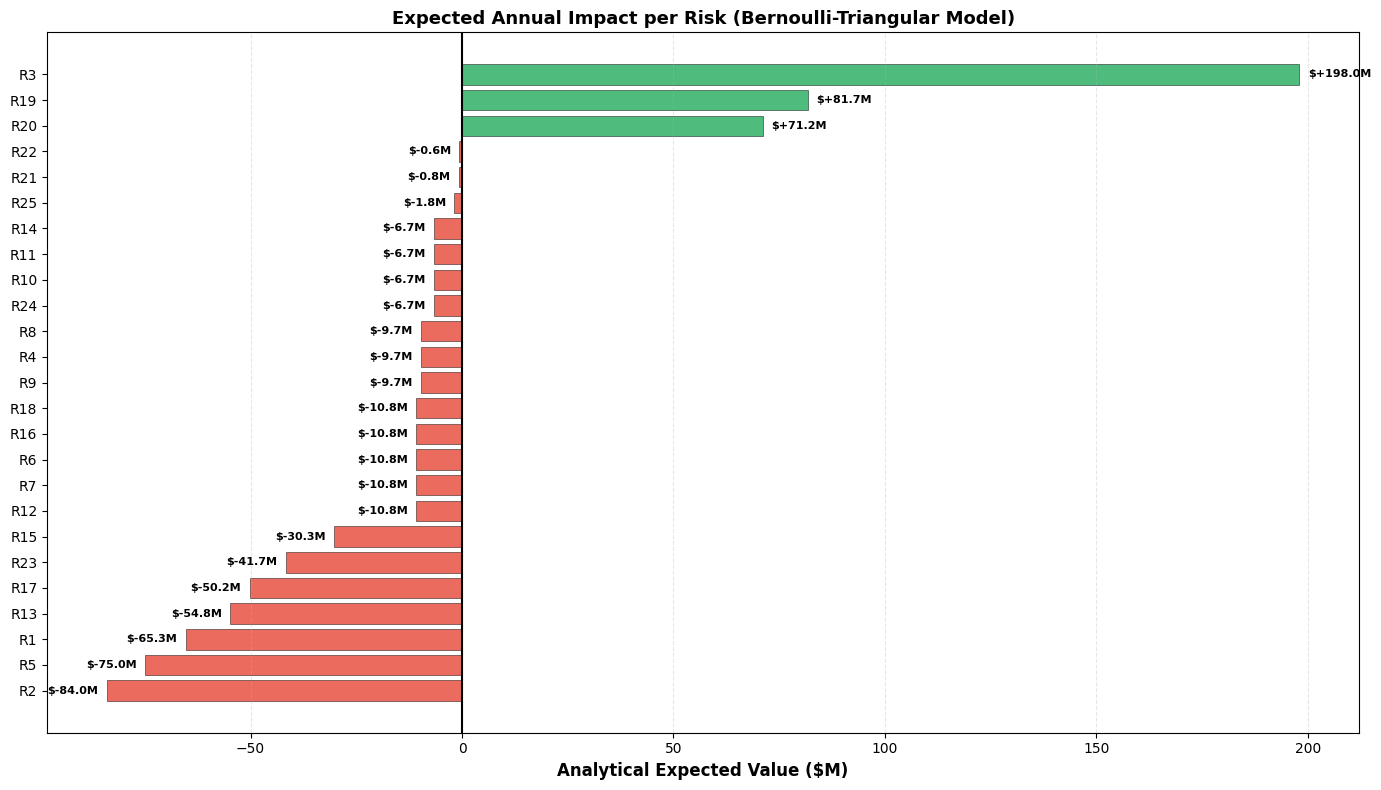

Sum positive EVs: $+350.9M
Sum negative EVs: $-514.3M
Net analytical EV: $-163.4M


In [10]:
ev_sorted = risk_register.sort_values('Expected_Value_M')
colors_ev = ['#27AE60' if v > 0 else '#E74C3C' for v in ev_sorted['Expected_Value_M']]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(ev_sorted['Risk_ID'], ev_sorted['Expected_Value_M'],
               color=colors_ev, edgecolor='black', linewidth=0.4, alpha=0.82)
ax.axvline(0, color='black', lw=1.5)
for bar, val in zip(bars, ev_sorted['Expected_Value_M']):
    xpos = val + (2 if val >= 0 else -2)
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'${val:+.1f}M', va='center', ha=ha, fontsize=8, fontweight='bold')
ax.set_xlabel('Analytical Expected Value ($M)', fontsize=12, fontweight='bold')
ax.set_title('Expected Annual Impact per Risk (Bernoulli-Triangular Model)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', axis='x')
plt.tight_layout()
plt.savefig('../report/eda_expected_values.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Sum positive EVs: ${ev_sorted[ev_sorted.Expected_Value_M > 0].Expected_Value_M.sum():+.1f}M')
print(f'Sum negative EVs: ${ev_sorted[ev_sorted.Expected_Value_M < 0].Expected_Value_M.sum():+.1f}M')
print(f'Net analytical EV: ${ev_sorted.Expected_Value_M.sum():+.1f}M')

## 4. KRI Status Summary

In [11]:
kri_summary = risk_register['KRI_Status'].value_counts()
print('KRI Status Summary:')
print(kri_summary)
print(f'\nOnly 1 Green, 1 Red, 23 Amber — portfolio is in elevated-caution state.')
print(f'R24 (Multi-Cloud Redundancy) is the only Red-status KRI.')
print(f'R3 (Regulatory Pipeline Growth) is the only Green-status KRI.')

KRI Status Summary:
KRI_Status
Amber    23
Green     1
Red       1
Name: count, dtype: int64

Only 1 Green, 1 Red, 23 Amber — portfolio is in elevated-caution state.
R24 (Multi-Cloud Redundancy) is the only Red-status KRI.
R3 (Regulatory Pipeline Growth) is the only Green-status KRI.


## Summary

The EDA confirms:
- 25 risks: 3 positive, 22 negative
- Priority: 8 HIGH, 14 MEDIUM, 3 LOW
- Net analytical expected value: -$163.5M
- Positive expected total: +$350.8M | Negative expected total: -$514.3M
- 23 of 25 KRIs in Amber, 1 Green (R3), 1 Red (R24)
- Strategic category has highest concentration of HIGH-priority risks